
## **🛠️ CNN to Inferno Pipeline Example for Running Different Predictions**

### **🧮 Probability Function**

For each combination of predictors $X$ and predictands $Y$, Inferno estimates the following probability:

$$
P(Y \mid X, \text{Data})
$$

Where explicitly it can be:

$$
P(\text{LABEL\_EFFUSION}, \text{LABEL\_ATELECTASIS} \mid \text{LOGIT\_EFFUSION}, \text{AGE}, \text{GENDER}, \text{VP})
$$

where:
- $X$ includes the CNN logits (e.g., `LOGIT_EFFUSION`) and optionally other auxiliary variables (e.g., `AGE`, `GENDER`, `VP`).
- $Y$ includes the posterior probabilities for the labels you want to predict (e.g., `LABEL_EFFUSION`, `LABEL_ATELECTASIS`).


─────────────────────────────────────────────  CNN Prediction Result ──────────────────────────────────────────────

           Model Output for Manual Input           
┏━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃    Label    ┃   Logit ┃ Confidence ┃ Prediction ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│  Effusion   │  0.2133 │     0.5531 │          1 │
├─────────────┼─────────┼────────────┼────────────┤
│ Atelectasis │ -1.1898 │     0.2333 │          0 │
└─────────────┴─────────┴────────────┴────────────┘

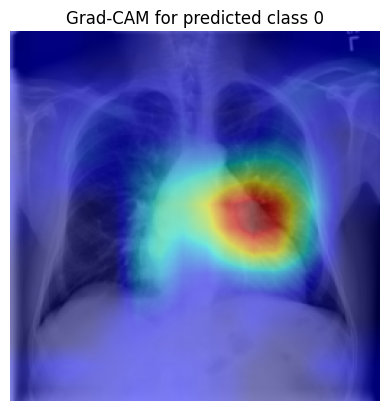

────────────────────────────────────────────── 🚀 Params for Inferno ──────────────────────────────────────────────

{
    'input_csv': 'data/inferno/calibration_test.csv',
    'model_path': 'data/inferno/combined_new_MT/learnt.rds',
    'quantiles': [0.055, 0.25, 0.75, 0.945],
    'input_values': {
        'LOGIT_ATELECTASIS': [None, None, None, None, -1.189772605895996],
        'AGE': [57, None, None, None, None],
        'GENDER': ['M', 'F', None, None, None],
        'LOGIT_EFFUSION': [1.09, 0.75, 0.75, 0.75, 0.2132999747991562],
        'VP': ['AP', 'PA'],
        'LABEL_EFFUSION': [0, 1],
        'LABEL_ATELECTASIS': [0, 1]
    },
    'predictors': ['LOGIT_ATELECTASIS', 'AGE', 'GENDER', 'LOGIT_EFFUSION'],
    'predictands': ['VP', 'LABEL_EFFUSION', 'LABEL_ATELECTASIS']
}

[1] "🔍 Predictor Features:"
  LOGIT_ATELECTASIS AGE GENDER LOGIT_EFFUSION
1                NA  57      M         1.0900
2                NA  NA      F         0.7500
3                NA  NA   <NA>         0.7500
4                NA  NA   <NA>         0.7500
5         -1.189773  NA   <NA>         0.2133
[1] "🔍 Predictand Targets:"
  VP LABEL_EFFUSION LABEL_ATELECTASIS
1 AP              0                 0
2 PA              0                 0
3 AP              1                 0
4 PA              1                 0
5 AP              0                 1
6 PA              0                 1
7 AP              1                 1
8 PA              1                 1


───────────────────────────────────────────────── Inferno Results ─────────────────────────────────────────────────

📊 Prediction Values:

0       1       2       3       4
0  0.0765  0.1039  0.1067  0.1067  0.1384
1  0.0995  0.1092  0.1070  0.1070  0.1339
2  0.1972  0.2161  0.2270  0.2270  0.2335
3  0.3012  0.2590  0.2548  0.2548  0.2339
4  0.0421  0.0546  0.0548  0.0548  0.0566
5  0.0495  0.0534  0.0521  0.0521  0.0514
6  0.0971  0.0943  0.0936  0.0936  0.0756
7  0.1369  0.1095  0.1040  0.1040  0.0768

In [3]:
import os
from pathlib import Path
from CNN import run_inferno_prediction, predict_from_image_path

# Move the working directory to the parent folder
WORKDIR = Path("/home/maxvill/InfernoCalibNet") 
os.chdir(WORKDIR)

# Retrieving logits from CNN for a given image
(logit_efu, logit_ate), *_ = predict_from_image_path(image_path="/home/maxvill/InfernoCalibNet/data/raw/xrays/xrays1/00000001_000.png")

# Define predictors & predictands
predictor_sets = [
    {"LOGIT_EFFUSION": 1.09, "AGE": 57, "GENDER": "M"},
    {"LOGIT_EFFUSION": 0.75, "GENDER": "F"},
    {"LOGIT_EFFUSION": 0.75},
    {"LOGIT_EFFUSION": 0.75},
    {"LOGIT_EFFUSION": logit_efu, "LOGIT_ATELECTASIS": logit_ate}, 
]

predictand_input = {"VP": ["AP", "PA"], "LABEL_EFFUSION": [0, 1], "LABEL_ATELECTASIS": [0, 1]}

# Running Infeno prediction
# The original paths are set relative to root of project override for custom paths
df, result = run_inferno_prediction(
    predictor_sets=predictor_sets, predictand_input=predictand_input
)
